In [1]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np

In [2]:
path = "/kaggle/input/datasets/shegoworld/spotify-dataset/Spotify 2010 - 2019 Top 100.csv"
spotify = pd.read_csv(path)
spotify = spotify.dropna()

print(spotify.head())
print(spotify.shape)
print(spotify.dtypes)
print(spotify.isnull().sum())

                                           title      artist    top genre  \
0                  STARSTRUKK (feat. Katy Perry)       3OH!3    dance pop   
1                    My First Kiss (feat. Ke$ha)       3OH!3    dance pop   
2                                I Need A Dollar  Aloe Blacc     pop soul   
3  Airplanes (feat. Hayley Williams of Paramore)       B.o.B  atl hip hop   
4              Nothin' on You (feat. Bruno Mars)       B.o.B  atl hip hop   

   year released       added    bpm  nrgy  dnce   dB  live   val    dur  \
0         2009.0  2022‑02‑17  140.0  81.0  61.0 -6.0  23.0  23.0  203.0   
1         2010.0  2022‑02‑17  138.0  89.0  68.0 -4.0  36.0  83.0  192.0   
2         2010.0  2022‑02‑17   95.0  48.0  84.0 -7.0   9.0  96.0  243.0   
3         2010.0  2022‑02‑17   93.0  87.0  66.0 -4.0   4.0  38.0  180.0   
4         2010.0  2022‑02‑17  104.0  85.0  69.0 -6.0   9.0  74.0  268.0   

   acous  spch   pop  top year artist type  
0    0.0   6.0  70.0    2010.0         Du

In [3]:
print(spotify["top genre"].nunique())
print(spotify["artist"].nunique())
print(spotify["year released"].min(), spotify["year released"].max())

132
444
1975.0 2021.0


In [4]:
Which genres appear most?

Object `most` not found.


In [5]:
genre_counts = spotify["top genre"].value_counts().head(10).reset_index()
print(genre_counts)


          top genre  count
0         dance pop    361
1               pop     57
2       atl hip hop     39
3           art pop     37
4           hip hop     21
5          boy band     21
6  canadian hip hop     18
7               edm     17
8          folk-pop     15
9     barbadian pop     14


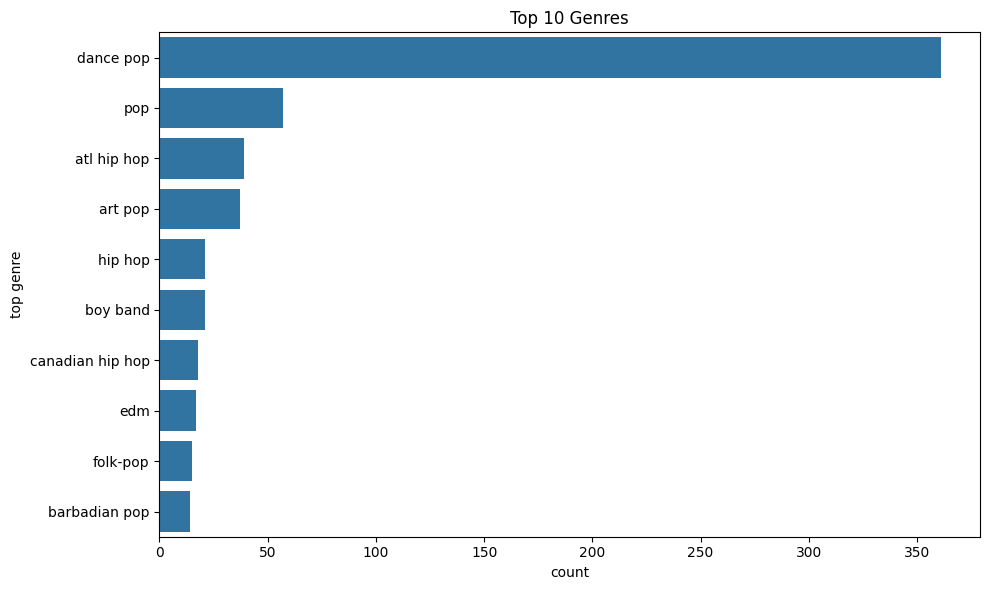

In [6]:
plt.figure(figsize=(10, 6))
plt.title("Top 10 Genres")
sns.barplot(data = genre_counts, x = "count", y = "top genre")
plt.tight_layout()

**Which artists have the most tracks?**

In [7]:
top_artists = spotify["artist"].value_counts().head(10).reset_index()
print(top_artists)

          artist  count
0   Taylor Swift     21
1          Drake     18
2  Calvin Harris     18
3        Rihanna     14
4  Ariana Grande     14
5     Bruno Mars     13
6       Maroon 5     11
7   Jason Derulo     10
8    Post Malone     10
9    Chris Brown     10


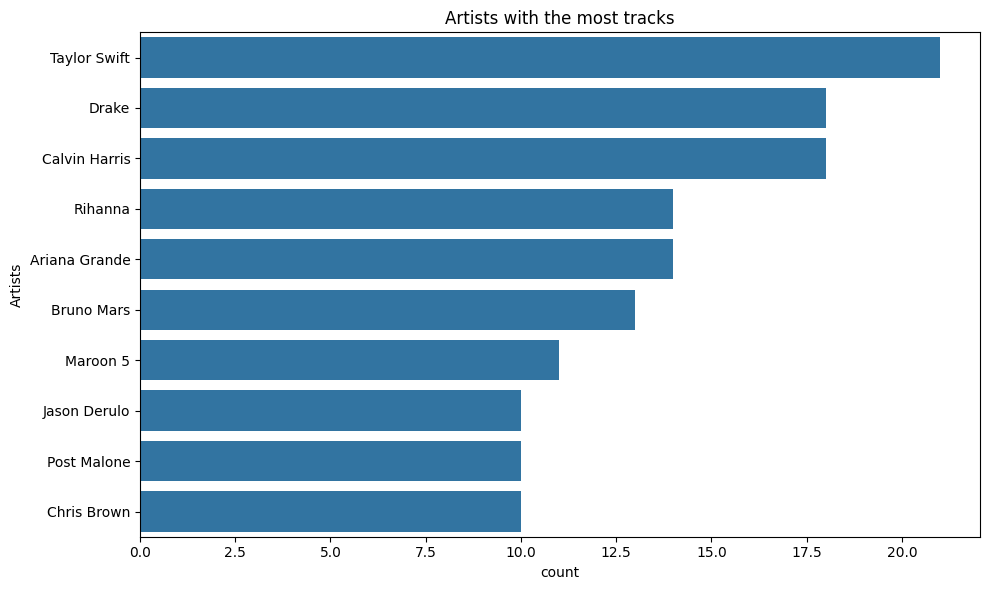

In [8]:
plt.figure(figsize=(10, 6))
plt.title("Artists with the most tracks")
sns.barplot(data = top_artists, x = "count", y = "artist")
plt.ylabel("Artists")
plt.tight_layout()

**Average popularity per genre (top 10 genres only)**

In [9]:
pop_genre = spotify.groupby("top genre")['pop'].mean().sort_values(ascending = False).head(10).reset_index()
print(pop_genre)

              top genre        pop
0             chill pop  94.000000
1         dark clubbing  89.000000
2      australian psych  88.000000
3           bedroom pop  88.000000
4               dfw rap  84.300000
5  alternative pop rock  84.000000
6            danish pop  83.000000
7      kentucky hip hop  82.333333
8          indietronica  82.250000
9         dutch hip hop  82.000000


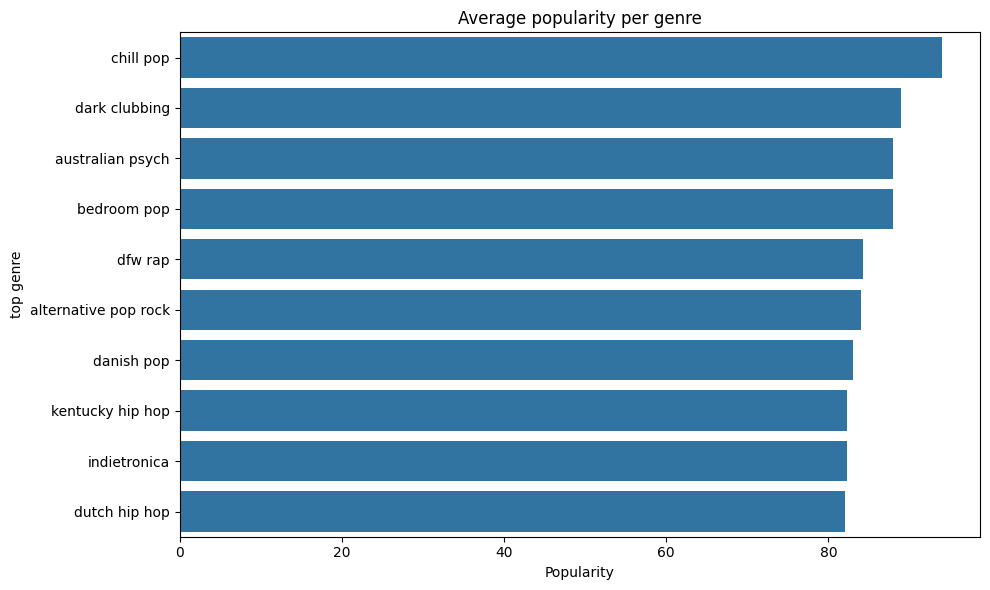

In [10]:
plt.figure(figsize=(10, 6))
plt.title("Average popularity per genre")
sns.barplot(data = pop_genre, x = "pop", y = "top genre")
plt.xlabel("Popularity")
plt.tight_layout()

**Top 10 most popular tracks**

In [11]:
pop_tracks = spotify.sort_values("pop", ascending=False)[["title", "artist", "pop"]].head(10)
print(pop_tracks)

                                        title             artist   pop
392                           Sweater Weather  The Neighbourhood  95.0
394                              Another Love          Tom Odell  94.0
316                      Locked out of Heaven         Bruno Mars  91.0
231                                      Lost        Frank Ocean  91.0
914                      lovely (with Khalid)      Billie Eilish  91.0
736                                  Believer    Imagine Dragons  91.0
809                      lovely (with Khalid)      Billie Eilish  91.0
211                      Locked out of Heaven         Bruno Mars  91.0
302  Why'd You Only Call Me When You're High?     Arctic Monkeys  90.0
442                                 All of Me        John Legend  90.0


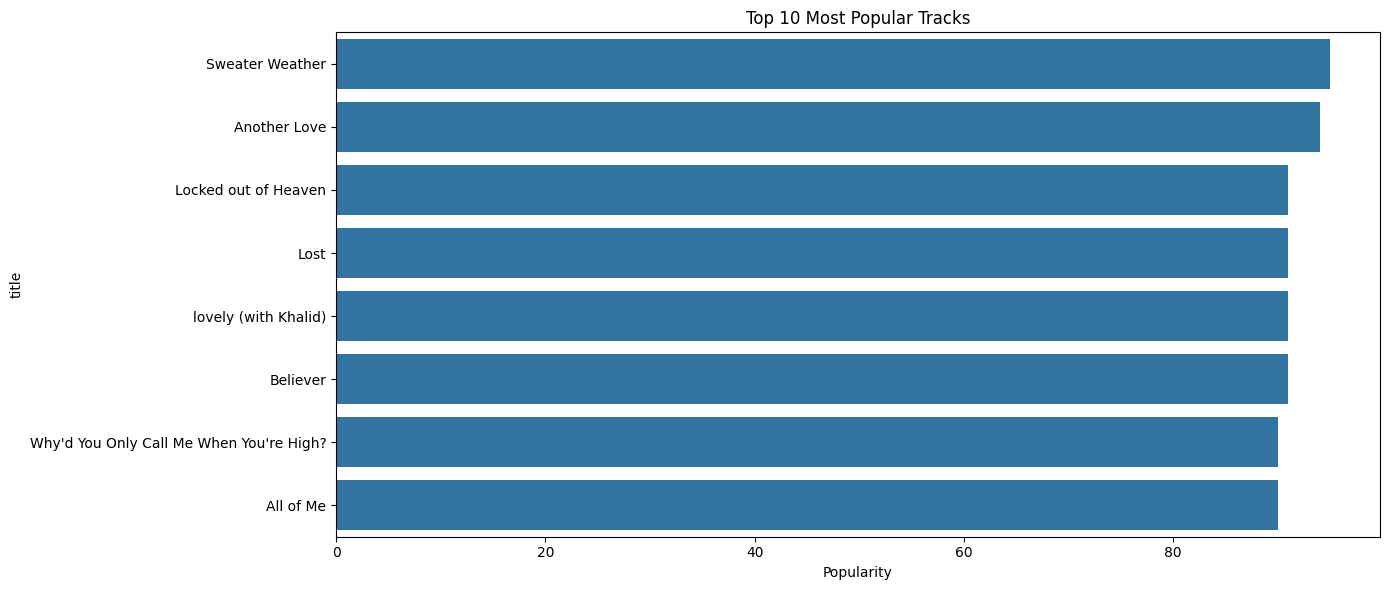

In [12]:
plt.figure(figsize=(14,6))
plt.title("Top 10 Most Popular Tracks")
sns.barplot(data=pop_tracks, x="pop", y="title")
plt.xlabel("Popularity")
plt.tight_layout()

**Relationship between energy and danceability**

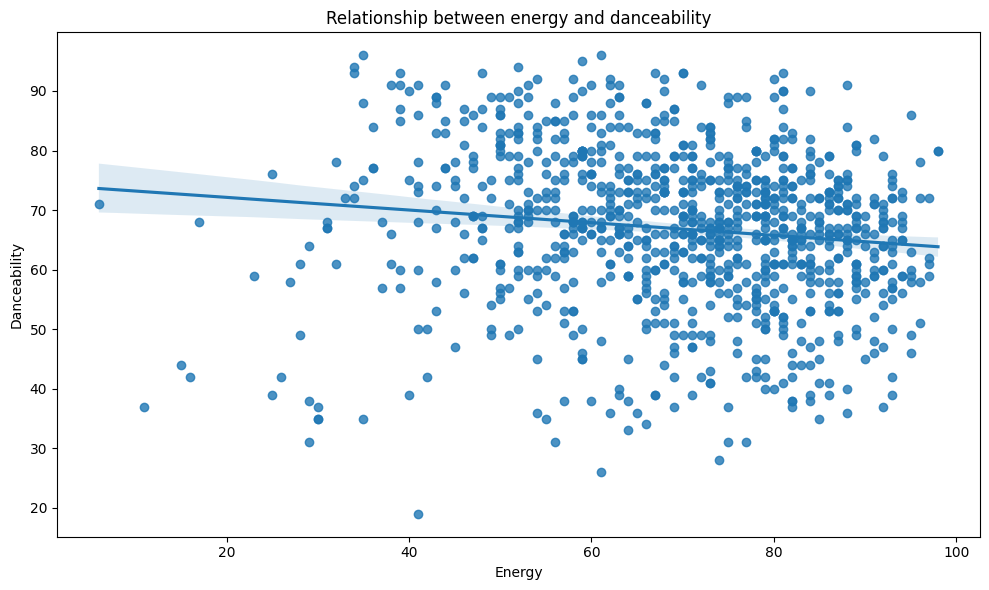

In [13]:
plt.figure(figsize=(10, 6))
plt.title("Relationship between energy and danceability")
sns.regplot(data = spotify, x = "nrgy", y = "dnce")
plt.xlabel("Energy")
plt.ylabel("Danceability")
plt.tight_layout()

**popularity trend over years**

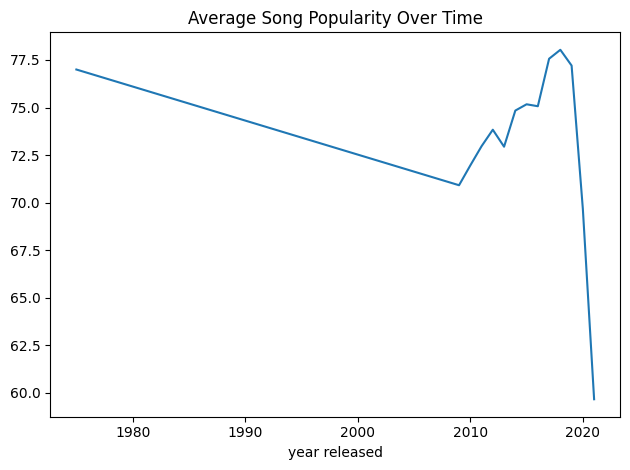

In [14]:
spotify.groupby("year released")["pop"].mean().plot(kind="line")
plt.title("Average Song Popularity Over Time")
plt.tight_layout()